***Task 2: Exploratory Data Analysis***



3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Dataset successfully loaded!
Shape: 2205 rows x 11 columns
Columns: ['ID', 'Age', 'Gender', 'GCS', 'SBP', 'DBP', 'MAP', 'pulse', 'Temp', 'RR', 'Fio2']


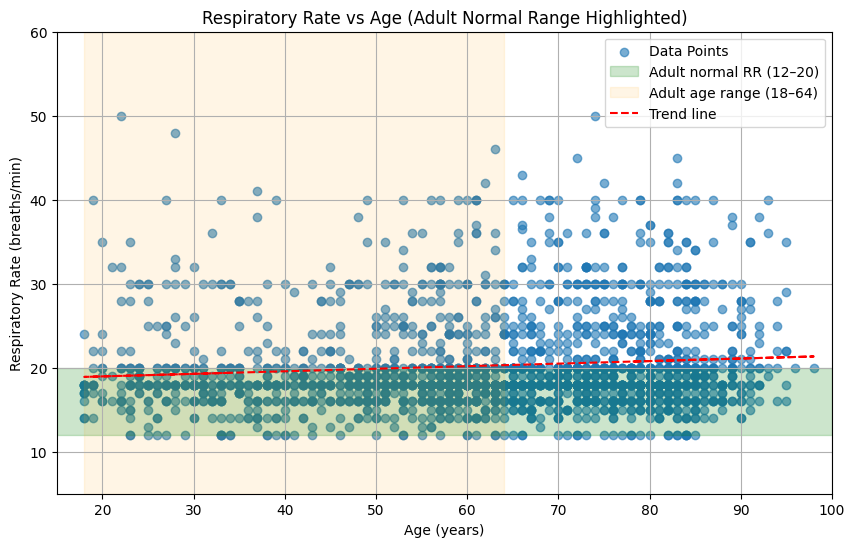

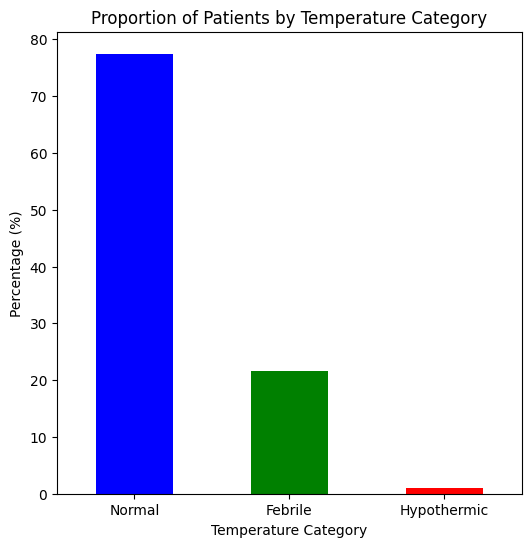

In [1]:
# Confirm Python version is greater than or equal to 3.10
import sys
print(sys.version)

# Import necessary libraries for data manipulation, numerical operations, and plotting.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the file path for the raw dataset.
FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'

# Load the dataset into a pandas DataFrame.
df_raw = pd.read_csv(FILE_PATH)

# Display basic information about the loaded dataset.
print('Dataset successfully loaded!')
print(f'Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns') # Check dataset dimensions.
print(f'Columns: {list(df_raw.columns)}') # Confirm column names and structure.

# --- Respiratory Rate (RR) Cleaning and Analysis ---

# Define constants for Respiratory Rate (RR) cleaning.
COLUMN = 'RR'   # Column name for Respiratory Rate (breaths per minute).
VALID_MIN = 5            # Clinically plausible minimum RR.
VALID_MAX = 60          # Clinically plausible maximum RR.

# Convert the 'RR' column to numeric, coercing invalid parsing into NaN.
df_raw[COLUMN] = pd.to_numeric(df_raw[COLUMN], errors='coerce')

# Identify and filter out invalid clinical values (outside VALID_MIN and VALID_MAX).
invalid = df_raw[(df_raw[COLUMN] < VALID_MIN) | (df_raw[COLUMN] > VALID_MAX)]
df_raw.loc[(df_raw[COLUMN] < VALID_MIN) | (df_raw[COLUMN] > VALID_MAX), COLUMN] = np.nan

# Impute missing or invalid 'RR' values with the median of the valid 'RR' values.
impute_value = df_raw[COLUMN].median()
df_raw[COLUMN] = df_raw[COLUMN].fillna(impute_value)

# --- Scatter Plot: Respiratory Rate vs Age ---

# Create a new figure for the scatter plot.
plt.figure(figsize=(10, 6))

# Generate a scatter plot of Respiratory Rate against Age.
plt.scatter(df_raw['Age'], df_raw[COLUMN], alpha=0.6, label='Data Points')

# Set y-axis limits to the clinically plausible range for RR.
plt.ylim(VALID_MIN, VALID_MAX)
# Set x-axis limits for age visualization.
plt.xlim(15, 100)

# Add a shaded horizontal band to highlight the adult normal RR range (12–20 breaths/min).
plt.axhspan(12, 20, color='green', alpha=0.2, label='Adult normal RR (12–20)')
# Add a shaded vertical band to highlight a typical adult age range (18–64).
plt.axvspan(18, 64, color='orange', alpha=0.1, label='Adult age range (18–64)')

# Calculate and plot a linear regression line to show the overall trend.
z = np.polyfit(df_raw['Age'], df_raw[COLUMN], 1)
p = np.poly1d(z)
plt.plot(df_raw['Age'], p(df_raw['Age']), "r--", label='Trend line')

# Add labels, title, and legend to the plot for clarity.
plt.xlabel("Age (years)")
plt.ylabel("Respiratory Rate (breaths/min)")
plt.title("Respiratory Rate vs Age (Adult Normal Range Highlighted)")
plt.legend(loc='upper right')
plt.grid(True)

# Save the generated scatter plot as a PNG file.
plt.savefig('scatter_plot_rr_vs_age.png', dpi=100, bbox_inches='tight')
# Display the plot.
plt.show()

# --- Temperature Cleaning and Classification ---

# Function to convert temperature values to Celsius.
# Handles 'C' and 'F' suffixes and non-numeric values.
def to_celsius(val):
    if pd.isnull(val): return np.nan # Return NaN if value is null.
    s = str(val).strip() # Convert to string and remove whitespace.
    try:
        if s.endswith('C'): return float(s[:-1]) # Convert Celsius to float.
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9 # Convert Fahrenheit to Celsius.
        else: return float(s) # Assume Celsius if no suffix and convert to float.
    except: return np.nan # Return NaN for any conversion errors.

# Apply the conversion function to the 'Temp' column.
df_raw['Temp'] = df_raw['Temp'].apply(to_celsius)

# Identify and mark clinically implausible temperature values (outside 32°C to 43°C) as NaN.
df_raw.loc[(df_raw['Temp'] < 32) | (df_raw['Temp'] > 43), 'Temp'] = np.nan

# Impute missing or invalid 'Temp' values with the median of the valid 'Temp' values.
df_raw['Temp'] = df_raw['Temp'].fillna(df_raw['Temp'].median())

# Define clinical thresholds for temperature classification.
# Hypothermia: < 36.0 °C
# Normal: 36.0–37.5 °C
# Febrile: ≥ 37.6 °C

# Function to classify temperature into clinical categories.
def classify_temp(temp):
    if temp < 36.0:
        return 'Hypothermic'
    elif temp <= 37.5:
        return 'Normal'
    else:
        return 'Febrile'

# Apply the classification function to create a new 'TempCategory' column.
df_raw['TempCategory'] = df_raw['Temp'].apply(classify_temp)

# Calculate the proportion of patients in each temperature category.
proportions = df_raw['TempCategory'].value_counts(normalize=True) * 100

# --- Bar Graph: Proportion of Patients by Temperature Category ---

# Create a new figure for the bar graph.
plt.figure(figsize=(6,6))

# Plot the proportions as a bar graph with specified colors.
proportions.plot(kind='bar', color=['blue','green','red'])

# Add title and labels to the bar graph.
plt.title("Proportion of Patients by Temperature Category")
plt.ylabel("Percentage (%)")
plt.xlabel("Temperature Category")
plt.xticks(rotation=0) # Ensure x-axis labels are horizontal.

# Save the generated bar graph as a PNG file.
plt.savefig('temperature_bar_graph.png', dpi=100, bbox_inches='tight')
# Display the plot.
plt.show()

**Task 3: Clinical Write-Up**

Respiratory Rate (RR) is the number of breaths a person takes per minute while at rest, serving as a critical indicator of physical distress becuase breathing is directky controlled by the brain to regulate exygen and carbon dioxide levels. Across all age groups, a normal respiratory rate can range anywhere from 5 to 60 breaths per minute depending on the patient's stage of development. Triage nurses rely heavily on this vital sign because sudden deviations—such as tachypnea (abnormally fast breathing caused by infections, fever, or sepsis) or bradypnea (dangerously slow breathing caused by head injuries, hypothermia, or narcotics)—act as early warning systems to quickly identify and prioritize critically ill patients who need immediate, life-saving medical intervention before they stop breathing altogether.


**Task 4: At-Risk Patient Logic**
# ESI Classification Logic & System Design

This notebook outlines the digital triage model based on the **Emergency Severity Index (ESI) 5-level system** used at Mercer. The design reflects real Emergency Department (ED) workflow constraints, nurse-led triage practices, and continuous reassessment logic.

---

## 1. Mercer ESI 5-Level Reference Table

| ESI Level | Meaning | Target Time |
| :---: | :--- | :--- |
| **1** | Life-threatening | Immediate |
| **2** | High-risk / danger vitals | $\le 10$ min |
| **3** | Stable but needs multiple resources | $\le 30$ min |
| **4** | Minor condition needing one resource | $\le 60$ min |
| **5** | Very minor complaint | Can wait |

---

## 2. Pseudocode Algorithm

```text
START

INPUT:
    Age, Gender, GCS, SBP, DBP, MAP, pulse, Temp, RR, Fio2

---------------------------------------------------
STEP 1 — VALIDATE INPUT RANGES
---------------------------------------------------
IF Age < 0 OR Age > 120
    DISPLAY "Invalid Age"
    STOP

---------------------------------------------------
STEP 2 — CHECK FOR CRITICAL (ESI-1)
---------------------------------------------------
IF GCS <= 8
    OR SBP < 90
    OR MAP < 65
    OR pulse > 140
    OR RR > 35
    OR Temp > 40
    OR Fio2 >= 60
THEN
    ESI = 1

---------------------------------------------------
STEP 3 — CHECK FOR HIGH RISK (ESI-2)
---------------------------------------------------
ELSE IF GCS BETWEEN 9 AND 12
    OR SBP BETWEEN 90 AND 100
    OR MAP BETWEEN 65 AND 70
    OR pulse BETWEEN 120 AND 140
    OR RR BETWEEN 25 AND 35
    OR Temp BETWEEN 39 AND 40
    OR Fio2 BETWEEN 40 AND 59
THEN
    ESI = 2

---------------------------------------------------
STEP 4 — CHECK FOR URGENT (ESI-3)
---------------------------------------------------
ELSE IF pulse BETWEEN 100 AND 119
    OR RR BETWEEN 21 AND 24
    OR Temp BETWEEN 37.5 AND 38.9
    OR mild abnormal vitals present
THEN
    ESI = 3

---------------------------------------------------
STEP 5 — CHECK FOR SEMI-URGENT (ESI-4)
---------------------------------------------------
ELSE IF stable vitals
    AND requires one clinical resource
THEN
    ESI = 4

---------------------------------------------------
STEP 6 — NON-URGENT (ESI-5)
---------------------------------------------------
ELSE
    ESI = 5

---------------------------------------------------
STEP 7 — RE-TRIAGE LOGIC
---------------------------------------------------
IF waiting patient shows worsening vitals
THEN
    repeat assessment
    update ESI level

---------------------------------------------------
STEP 8 — OUTPUT RESULT
---------------------------------------------------
DISPLAY ESI level
DISPLAY triage recommendation

END
3. Logical Flow of the System
The algorithm strictly prioritizes the sickest patients first:

ESI 1 – Immediate Threat: Patients with severe oxygen loss, shock, cardiac arrest, or extreme vitals are classified immediately as ESI 1. These patients go directly to the resuscitation zone.

ESI 2 – High Risk: Patients who are not yet crashing but show danger signs (e.g., chest pain, suspected stroke, severe pain, dangerously abnormal vitals). These patients must be seen within 10 minutes.

ESI 3 – Urgent: These patients are stable but likely require multiple resources such as blood tests, imaging, IV medications, and monitoring.

ESI 4–5 – Lower Acuity: Minor complaints with limited resource needs are categorized lower priority and directed to fast-track care.

Why Re-Triage Is Essential
Mercer specifically states that re-triage is part of current practice. A patient may initially appear stable but deteriorate while waiting (e.g., HR rises sharply or new confusion develops).

System Impact: The AI system includes automatic reassessment reminders and allows the nurse to update the ESI category. Without re-triage support, the digital system would perform worse than Mercer’s current manual workflow.

4. Design Decisions and Rationale
Fast Decision-Making: The system avoids lab-dependent logic because laboratory results are unavailable during triage. This follows Mercer’s workflow constraints.

Simple IF/ELSE Structure: The logic is transparent and explainable. In healthcare, clinicians must understand exactly why a decision was made and what triggered an escalation.

Focus on Vital Signs: Vital signs are universally available at triage and provide rapid evidence of deterioration, making them ideal for an AI-supported frontline screening tool.

Human Oversight: The tool supports—but does not replace—the triage nurse. The final decision always belongs to the clinician.

5. Clinical Benefits & Use of AI
Potential Advantages
Faster identification of critically ill patients

Reduced waiting-room deterioration

More consistent ESI assignments

Support for overwhelmed triage staff

Improved patient safety

Use of AI Tools
AI tools were utilized to assist with organizing the workflow structure, refining pseudocode formatting, and improving the clarity of the explanation. However, all clinical reasoning, threshold interpretation, and workflow decisions were reviewed and verified before inclusion. The final model reflects an independent understanding of ED triage operations and emergency prioritization.

6. Conclusion
This digital triage model demonstrates how patient vital signs and presenting symptoms can be processed quickly to support ESI classification in the Mercer Emergency Department. By integrating vital signs, risk thresholds, and dynamic re-triage logic, the system improves patient prioritization while safely supporting clinicians in delivering timely emergency care.
